In [1]:
# importing pandas library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
import matplotlib.ticker as mtick
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from scipy.stats import wilcoxon
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind

In [2]:
path = "D:/S2S_FE/Indonesia_data/df.csv"
path1 = "D:/S2S_FE/SA_data/df_SA.csv"
path2 = "D:/S2S_FE/BGD_data/BGD_data1/df_bangladesh.csv"

df_indonesia = pd.read_csv(path)
df_southafrica = pd.read_csv(path1)
df_bangladesh = pd.read_csv(path2)

df_bangladesh = df_bangladesh[~df_bangladesh["cohort"].isin([1, 2])]

In [3]:
# keep only the columns for indonesia
df_indonesia = df_indonesia[[
    "country",
    "time_lsa",
    "id",
    "gender",
    "life_skill_score",
    "employability_score",
    "mindset_score"
]]

# keep only the columns for south africa
df_southafrica = df_southafrica[[
    "country",
    "time_lsa",
    "id",
    "gender",
    "life_skill_score",
    "employability_score",
    "mindset_score"
]]

# keep only the columns for banglades
df_bangladesh = df_bangladesh[[
    "country",
    "time_lsa",
    "id",
    "gender",
    "life_skill_score",
    "employability_score",
    "mindset_score"
]]

In [4]:
df = pd.concat([df_indonesia,df_southafrica,df_bangladesh], ignore_index=True)

print("Concatenated DataFrame size:", df.shape)

Concatenated DataFrame size: (6854, 7)


In [5]:
df.head()

,country,time_lsa,id,gender,life_skill_score,employability_score,mindset_score
0,Indonesia,pre,2765.0,1.0,110.0,42.0,76.0
1,Indonesia,pre,2902.0,1.0,93.0,35.0,71.0
2,Indonesia,pre,15970.0,1.0,94.0,34.0,59.0
3,Indonesia,pre,2889.0,1.0,124.0,48.0,84.0
4,Indonesia,pre,2895.0,1.0,93.0,33.0,65.0


In [6]:
df_pre = df[df['time_lsa'] == 'pre']
df_post = df[df['time_lsa'] == 'post']

In [7]:
# Checking for duplicated Id in pre dataframe
pre_has_duplicates = df_pre['id'].duplicated().any()

print("Duplicates found!" if pre_has_duplicates else "No duplicates found.")

No duplicates found.


In [8]:
# Checking for duplicated Id in post dataframe
pre_has_duplicates = df_post['id'].duplicated().any()

print("Duplicates found!" if pre_has_duplicates else "No duplicates found.")

No duplicates found.


In [9]:
df.to_csv("D:/S2S_FE/BGD_data/BGD_data1/df_all.csv",index =False)

#### 1.Pre and post univariate Life Skills Analysis

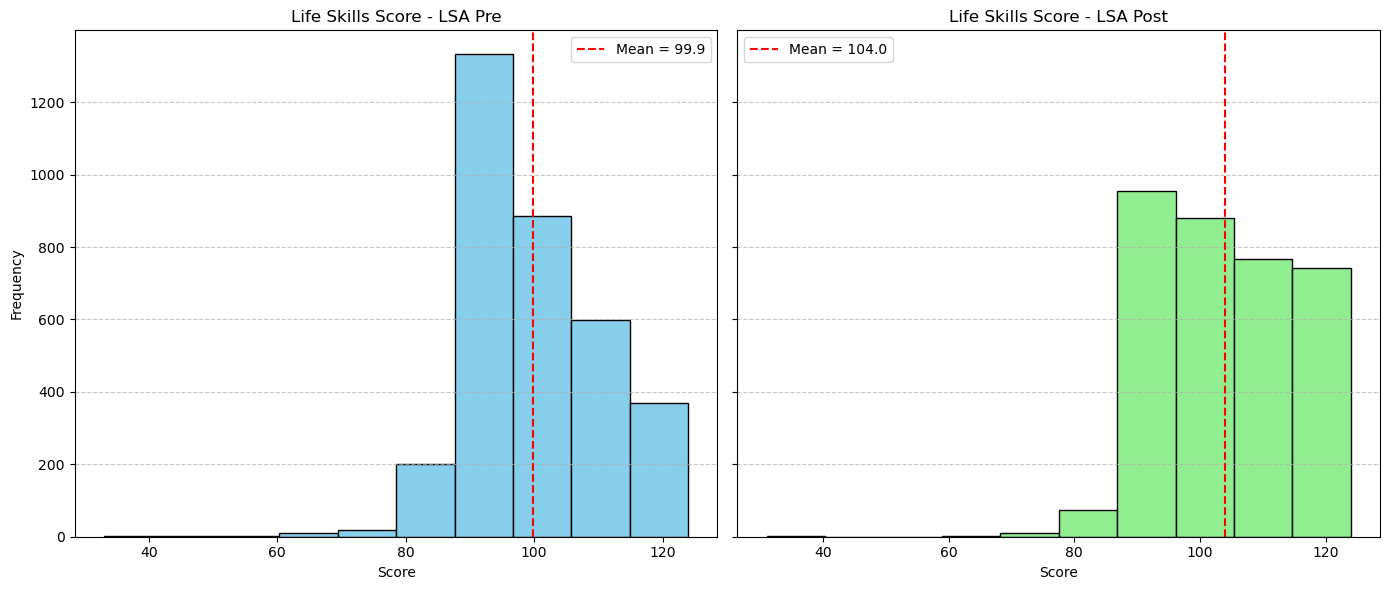

In [11]:
# SIDE BY SID HISTOGRAM

# Calculate means for insights
mean_pre = df_pre["life_skill_score"].mean()
mean_post = df_post["life_skill_score"].mean()

# Create side-by-side histograms for understanding self in pre and post in year 1
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

# Plot Pre
axes[0].hist(df_pre["life_skill_score"].dropna(), bins=10, edgecolor='black', color='skyblue')
axes[0].axvline(mean_pre, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean = {mean_pre:.1f}")
axes[0].set_title("Life Skills Score - LSA Pre")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend()

# Plot Post
axes[1].hist(df_post["life_skill_score"].dropna(), bins=10, edgecolor='black', color='lightgreen')
axes[1].axvline(mean_post, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean = {mean_post:.1f}")
axes[1].set_title("Life Skills Score - LSA Post")
axes[1].set_xlabel("Score")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

In [12]:
# Descriptive stats
summary = {
    "Pre": df_pre["life_skill_score"].describe(),
    "Post": df_post["life_skill_score"].describe()
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T

# Calculate standard error of the mean (SEM)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

# 95% confidence interval using z = 1.96
z = 1.96
summary_df["mean_CI_lower"] = summary_df["mean"] - z * summary_df["sem"]
summary_df["mean_CI_upper"] = summary_df["mean"] + z * summary_df["sem"]

# Round for cleaner display
summary_df = summary_df.round(2)

# Optional: drop SEM column if you don’t want it in the final output
# summary_df.drop(columns=["sem"], inplace=True)

# Display the updated summary
summary_df

,count,mean,std,min,25%,50%,75%,max,sem,mean_CI_lower,mean_CI_upper
Pre,3422.0,99.89,10.63,33.0,92.0,98.0,107.0,124.0,0.18,99.53,100.24
Post,3432.0,104.04,10.80,31.0,95.0,103.0,113.0,124.0,0.18,103.68,104.41


In [13]:
# Filter Pre and keep only 'id' and 'life_skill_score'
df_pre = df[(df["time_lsa"] == "pre")]                         # 👉 Filters df to include only YPre-training records.
df_pre = df_pre[["id", "life_skill_score"]]                    #👉 Keeps only id &  life_skill_score columns from the filtered data.
df_pre = df_pre.rename(columns={"life_skill_score": "life_skill_pre"}) # 👉 Renames the life_skill_score column 
                                                           

# Filter Post and keep only 'id' and 'life_skill_score'
df_post = df[(df["time_lsa"] == "post")]                        #👉 Filters df to include only Post-training records.
df_post = df_post[["id", "life_skill_score"]]                   # 👉 Keeps only id & life_skill_score columns from the filtered data.
df_post = df_post.rename(columns={"life_skill_score": "life_skill_post"}) # 👉 Renames the life_skill_score column 

# Merge Pre and Post datasets on 'id'
merged_df = pd.merge(df_pre, df_post, on="id", how="inner")      # 👉 Merges the Pre and Post datasets by matching IDs,
                                                                 # so we have both scores side by side for each respondent.
                                                                       

# Drop rows with missing values in either score column
paired_data = merged_df.dropna(subset=["life_skill_pre", "life_skill_post"])     # 👉 Removes any rows where a participant is
                                                                                 # missing either a pre- or post-score.
                                                                                # Wilcoxon requires complete pairs to work properly.
# Run the Wilcoxon signed-rank test
stat, p_value = wilcoxon(
    paired_data["life_skill_pre"],
    paired_data["life_skill_post"]
)

# Display the test statistic and p-value
print("Wilcoxon Test Statistic:", stat)
print("p-value:", p_value)               

Wilcoxon Test Statistic: 1721846.5
p-value: 5.920255737100009e-68


#### 2. Pre and post univariate Employability Score Analysis

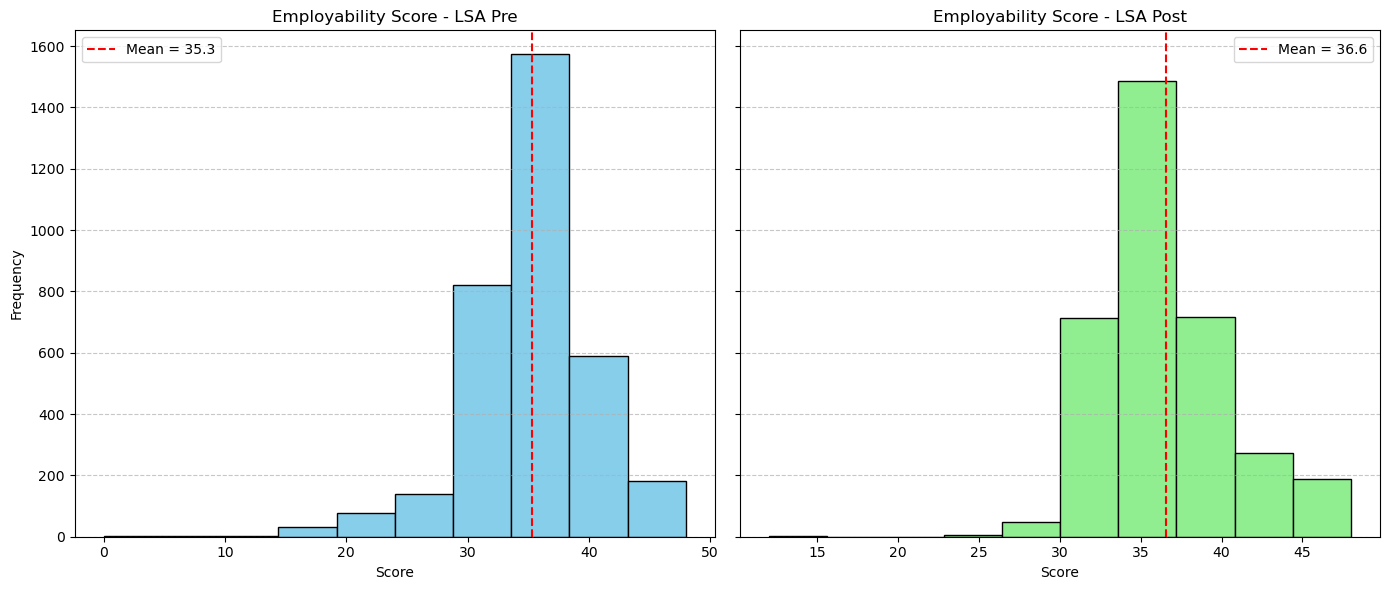

In [15]:
# SIDE BY SID HISTOGRAM

df_pre = df[df['time_lsa'] == 'pre']
df_post = df[df['time_lsa'] == 'post']

# Calculate means for insights
mean_pre = df_pre["employability_score"].mean()
mean_post = df_post["employability_score"].mean()

# Create side-by-side histograms for understanding self in pre and post in year 1
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

# Plot Pre
axes[0].hist(df_pre["employability_score"].dropna(), bins=10, edgecolor='black', color='skyblue')
axes[0].axvline(mean_pre, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean = {mean_pre:.1f}")
axes[0].set_title("Employability Score - LSA Pre")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend()

# Plot Post
axes[1].hist(df_post["employability_score"].dropna(), bins=10, edgecolor='black', color='lightgreen')
axes[1].axvline(mean_post, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean = {mean_post:.1f}")
axes[1].set_title("Employability Score - LSA Post")
axes[1].set_xlabel("Score")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:
# Create a dictionary of descriptive stats
summary = {
    "Pre": df_pre["employability_score"].describe(),
    "Post": df_post["employability_score"].describe()
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T

# Calculate standard error of the mean (SEM)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

# 95% confidence interval using z = 1.96
z = 1.96
summary_df["mean_CI_lower"] = summary_df["mean"] - z * summary_df["sem"]
summary_df["mean_CI_upper"] = summary_df["mean"] + z * summary_df["sem"]

# Round for cleaner display
summary_df = summary_df.round(2)

# Optional: drop SEM column if you don’t want it in the final output
# summary_df.drop(columns=["sem"], inplace=True)

# Display the updated summary
summary_df

,count,mean,std,min,25%,50%,75%,max,sem,mean_CI_lower,mean_CI_upper
Pre,3422.0,35.32,5.27,0.0,33.0,36.0,38.0,48.0,0.09,35.15,35.5
Post,3432.0,36.57,4.01,12.0,34.0,36.0,39.0,48.0,0.07,36.44,36.7


In [17]:
# Filter Pre and keep only 'id' and 'employability_score'
df_pre = df[(df["time_lsa"] == "pre")]                         # 👉 Filters df to include only YPre-training records.
df_pre = df_pre[["id", "employability_score"]]                    #👉 Keeps only id &  employability score columns from the filtered data.
df_pre = df_pre.rename(columns={"employability_score": "employability_pre"}) # 👉 Renames the life_skill_score column 
                                                           

# Filter Post and keep only 'id' and 'employability_score'
df_post = df[(df["time_lsa"] == "post")]                        #👉 Filters df to include only Post-training records.
df_post = df_post[["id", "employability_score"]]                   # 👉 Keeps only id & employability_score columns from the filtered data.
df_post = df_post.rename(columns={"employability_score": "employability_post"}) # 👉 Renames the employability_score column 

# Merge Pre and Post datasets on 'id'
merged_df = pd.merge(df_pre, df_post, on="id", how="inner")      # 👉 Merges the Pre and Post datasets by matching IDs,
                                                                 # so we have both scores side by side for each respondent.
                                                                       

# Drop rows with missing values in either score column
paired_data = merged_df.dropna(subset=["employability_pre", "employability_post"])     # 👉 Removes any rows where a participant is
                                                                                 # missing either a pre- or post-score.
                                                                                # Wilcoxon requires complete pairs to work properly.
# Run the Wilcoxon signed-rank test
stat, p_value = wilcoxon(
    paired_data["employability_pre"],
    paired_data["employability_post"]
)

# Display the test statistic and p-value
print("Wilcoxon Test Statistic:", stat)
print("p-value:", p_value)

Wilcoxon Test Statistic: 1837806.0
p-value: 2.57168988742868e-27


#### 3. Pre and post univariate Growth mindset analysis

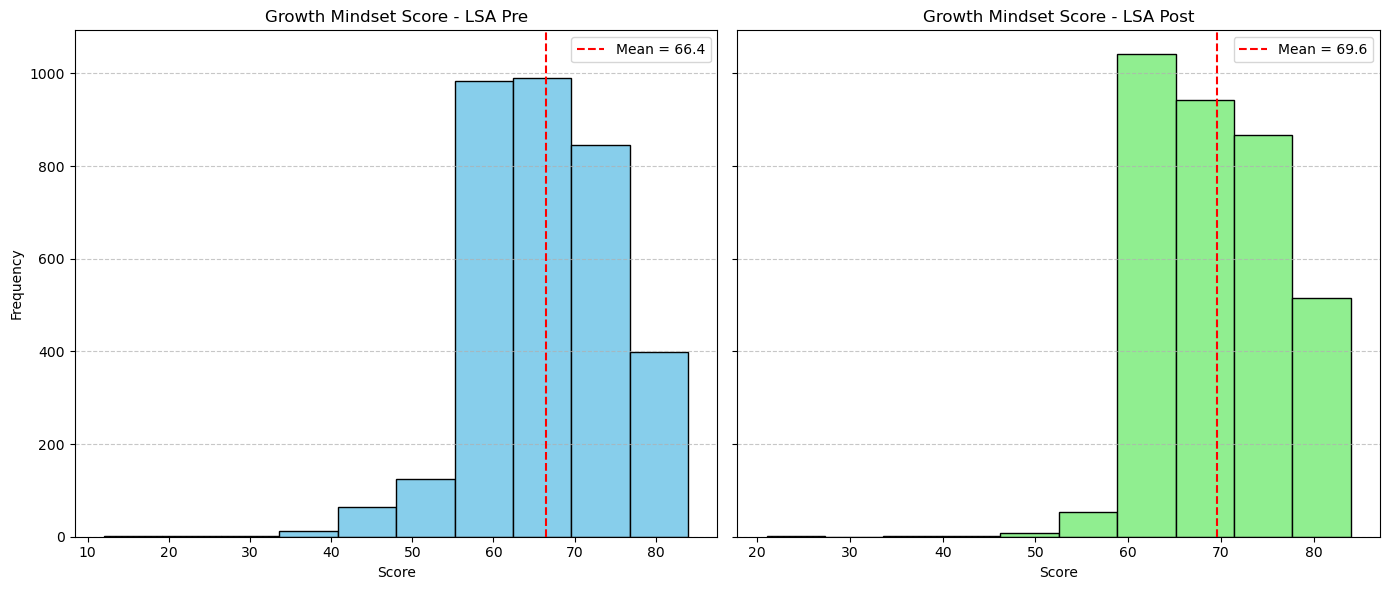

In [19]:
# SIDE BY SID HISTOGRAM

df_pre = df[df['time_lsa'] == 'pre']
df_post = df[df['time_lsa'] == 'post']

# Calculate means for insights
mean_pre = df_pre["mindset_score"].mean()
mean_post = df_post["mindset_score"].mean()

# Create side-by-side histograms for understanding self in pre and post 
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6), sharey=True)

# Plot Pre
axes[0].hist(df_pre["mindset_score"].dropna(), bins=10, edgecolor='black', color='skyblue')
axes[0].axvline(mean_pre, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean = {mean_pre:.1f}")
axes[0].set_title("Growth Mindset Score - LSA Pre")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Frequency")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend()

# Plot Post
axes[1].hist(df_post["mindset_score"].dropna(), bins=10, edgecolor='black', color='lightgreen')
axes[1].axvline(mean_post, color='red', linestyle='dashed', linewidth=1.5, label=f"Mean = {mean_post:.1f}")
axes[1].set_title("Growth Mindset Score - LSA Post")
axes[1].set_xlabel("Score")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
# Create a dictionary of descriptive stats
summary = {
    "Pre": df_pre["mindset_score"].describe(),
    "Post": df_post["mindset_score"].describe()
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T

# Calculate standard error of the mean (SEM)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

# 95% confidence interval using z = 1.96
z = 1.96
summary_df["mean_CI_lower"] = summary_df["mean"] - z * summary_df["sem"]
summary_df["mean_CI_upper"] = summary_df["mean"] + z * summary_df["sem"]

# Round for cleaner display
summary_df = summary_df.round(2)

# Optional: drop SEM column if you don’t want it in the final output
# summary_df.drop(columns=["sem"], inplace=True)

# Display the updated summary
summary_df

,count,mean,std,min,25%,50%,75%,max,sem,mean_CI_lower,mean_CI_upper
Pre,3422.0,66.42,8.24,12.0,61.0,65.0,72.0,84.0,0.14,66.15,66.70
Post,3432.0,69.62,6.90,21.0,64.0,69.5,75.0,84.0,0.12,69.39,69.85


In [21]:
# Filter Pre and keep only 'id' and 'mindset_score'
df_pre = df[(df["time_lsa"] == "pre")]                         # 👉 Filters df to include only Pre-training records.
df_pre = df_pre[["id", "mindset_score"]]                    #👉 Keeps only id &  mindset _score columns from the filtered data.
df_pre = df_pre.rename(columns={"mindset_score": "mindset_pre"}) # 👉 Renames the mindset_score column 
                                                           

# Filter Post and keep only 'id' and 'mindset_score'
df_post = df[(df["time_lsa"] == "post")]                        #👉 Filters df to include only Post-training records.
df_post = df_post[["id", "mindset_score"]]                   # 👉 Keeps only id & mindset_score columns from the filtered data.
df_post = df_post.rename(columns={"mindset_score": "mindset_post"}) # 👉 Renames the mindset_score column 

# Merge Pre and Post datasets on 'id'
merged_df = pd.merge(df_pre, df_post, on="id", how="inner")      # 👉 Merges the Pre and Post datasets by matching IDs,
                                                                 # so we have both scores side by side for each respondent.
                                                                       

# Drop rows with missing values in either score column
paired_data = merged_df.dropna(subset=["mindset_pre", "mindset_post"])     # 👉 Removes any rows where a participant is
                                                                                 # missing either a pre- or post-score.
                                                                                # Wilcoxon requires complete pairs to work properly.
# Run the Wilcoxon signed-rank test
stat, p_value = wilcoxon(
    paired_data["mindset_pre"],
    paired_data["mindset_post"]
)

# Display the test statistic and p-value
print("Wilcoxon Test Statistic:", stat)
print("p-value:", p_value)

Wilcoxon Test Statistic: 1652456.5
p-value: 1.0601931228106403e-65


### 4. Change scores (using post and pre difference score)

In [23]:
df_pre = df[(df["time_lsa"] == "pre")]
df_post = df[(df["time_lsa"] == "post")]

# Select and rename relevant columns
df_pre = df_pre[["id", "life_skill_score", "employability_score","mindset_score"]].rename(
    columns={
        "life_skill_score": "life_skill_pre",
        "employability_score": "employability_pre",
        "mindset_score": "mindset_pre"
    }
)

df_post = df_post[["id", "life_skill_score", "employability_score","mindset_score"]].rename(
    columns={
        "life_skill_score": "life_skill_post",
        "employability_score": "employability_post",
        "mindset_score": "mindset_post"
    }
)

# Merge Pre and Post datasets on 'id'
df_merged = pd.merge(df_pre, df_post, on="id", how="inner")

# Drop rows with missing values
df_merged = df_merged.dropna(subset=[
    "life_skill_pre", "life_skill_post",
    "employability_pre", "employability_post",
    "mindset_pre", "mindset_post"
])

# Compute change scores
df_merged["life_skill_change"] = df_merged["life_skill_post"] - df_merged["life_skill_pre"]
df_merged["employability_change"] = df_merged["employability_post"] - df_merged["employability_pre"]
df_merged["mindset_change"] = df_merged["mindset_post"] - df_merged["mindset_pre"]

__4.1. Percentage of  youth witgh a growth mindset positive__

In [25]:
positive_change_mindset = df_merged['mindset_change'] > 0
# Calculate the percentage
percentage = positive_change_mindset.mean() * 100
print(f"Percentage of youth with a positive change in Growth mindset: {percentage:.2f}%")

Percentage of youth with a positive change in Growth mindset: 57.50%


__4.2. Percentage of  youth with a life_skills positive change__

In [27]:
positive_change_lifeskill = df_merged['life_skill_change'] > 0
# Calculate the percentage
percentage = positive_change_lifeskill.mean() * 100
print(f"Percentage of youth with a positive change in life skills: {percentage:.2f}%")

Percentage of youth with a positive change in life skills: 58.84%


__4.3.Percentage of  youth with a employability positive change__

In [29]:
positive_change_employability = df_merged['employability_change'] > 0
# Calculate the percentage
percentage = positive_change_employability.mean() * 100
print(f"Percentage of youth with a positive change in employability: {percentage:.2f}%")

Percentage of youth with a positive change in employability: 51.62%


__4.5  Correlation between change scores__

In [31]:
# Calculate Spearman correlation between change scores
correlation_matrix = df_merged[["life_skill_change", "employability_change","mindset_change"]].corr(method="spearman")

# Output the result
correlation_matrix

,life_skill_change,employability_change,mindset_change
life_skill_change,1.000000,0.542670,0.678227
employability_change,0.542670,1.000000,0.735159
mindset_change,0.678227,0.735159,1.000000


### 5. Change scores (using Interval confidence method)

In [33]:
# EMPLOYABILITY

# Filter for pre and post across all years (or adjust if needed)
df_pre = df[df["time_lsa"] == "pre"]
df_post = df[df["time_lsa"] == "post"]

# Reliability for the Core Module
reliability = 0.918

# Calculate standard deviation for employability_score
sd_pre = df_pre["employability_score"].std()
sd_post = df_post["employability_score"].std()

# Standard Error of Measurement
sem_pre = sd_pre * np.sqrt(1 - reliability)
sem_post = sd_post * np.sqrt(1 - reliability)

# Z-value for 95% confidence interval
z = 1.96

# Build confidence intervals
df_pre = df_pre.copy()
df_post = df_post.copy()

df_pre["CI_lower"] = df_pre["employability_score"] - (sem_pre * z)
df_pre["CI_upper"] = df_pre["employability_score"] + (sem_pre * z)

df_post["CI_lower"] = df_post["employability_score"] - (sem_post * z)
df_post["CI_upper"] = df_post["employability_score"] + (sem_post * z)

# Merge the pre and post data on student ID
comparison_employability = pd.merge(
    df_pre[["id", "employability_score", "CI_lower", "CI_upper"]],
    df_post[["id", "employability_score", "CI_lower", "CI_upper"]],
    on="id",
    suffixes=("_pre", "_post")
)

# Define interpretation logic
def interpret(row):
    if row["CI_lower_post"] > row["CI_upper_pre"]:
        return "Case 1: Meaningful Improvement"
    else:
        return "Case 2: No Clear Improvement"

# Apply the logic to each row
comparison_employability["interpretation"] = comparison_employability.apply(interpret, axis=1)

# Calculate the number and percentage of students with meaningful improvement
num_improved = (comparison_employability["interpretation"] == "Case 1: Meaningful Improvement").sum()
total_students = comparison_employability.shape[0]
percent_improved = (num_improved / total_students) * 100

# Output the results
print(f"Number of students with meaningful improvement in employability: {num_improved}")
print(f"Percentage of students with meaningful improvement in employability: {percent_improved:.2f}%")

Number of students with meaningful improvement in employability: 644
Percentage of students with meaningful improvement in employability: 18.82%


In [34]:
# GROWTH MINDSET

# Filter for pre and post across all years (or adjust if needed)
df_pre = df[df["time_lsa"] == "pre"]
df_post = df[df["time_lsa"] == "post"]

# Reliability for the Core Module
reliability = 0.918

# Calculate standard deviation for employability_score
sd_pre = df_pre["mindset_score"].std()
sd_post = df_post["mindset_score"].std()

# Standard Error of Measurement
sem_pre = sd_pre * np.sqrt(1 - reliability)
sem_post = sd_post * np.sqrt(1 - reliability)

# Z-value for 95% confidence interval
z = 1.96

# Build confidence intervals
df_pre = df_pre.copy()
df_post = df_post.copy()

df_pre["CI_lower"] = df_pre["mindset_score"] - (sem_pre * z)
df_pre["CI_upper"] = df_pre["mindset_score"] + (sem_pre * z)

df_post["CI_lower"] = df_post["mindset_score"] - (sem_post * z)
df_post["CI_upper"] = df_post["mindset_score"] + (sem_post * z)

# Merge the pre and post data on student ID
comparison_mindset = pd.merge(
    df_pre[["id", "mindset_score", "CI_lower", "CI_upper"]],
    df_post[["id", "mindset_score", "CI_lower", "CI_upper"]],
    on="id",
    suffixes=("_pre", "_post")
)

# Define interpretation logic
def interpret(row):
    if row["CI_lower_post"] > row["CI_upper_pre"]:
        return "Case 1: Meaningful Improvement"
    else:
        return "Case 2: No Clear Improvement"

# Apply the logic to each row
comparison_mindset["interpretation"] = comparison_mindset.apply(interpret, axis=1)

# Calculate the number and percentage of students with meaningful improvement
num_improved = (comparison_mindset["interpretation"] == "Case 1: Meaningful Improvement").sum()
total_students = comparison_mindset.shape[0]
percent_improved = (num_improved / total_students) * 100

# Output the results
print(f"Number of students with meaningful improvement in mindset: {num_improved}")
print(f"Percentage of students with meaningful improvement in mindset: {percent_improved:.2f}%")

Number of students with meaningful improvement in mindset: 896
Percentage of students with meaningful improvement in mindset: 26.19%


In [35]:
# LIFE SKILL

# Filter for pre and post across all years (or adjust if needed)
df_pre = df[df["time_lsa"] == "pre"]
df_post = df[df["time_lsa"] == "post"]

# Reliability for the Core Module
reliability = 0.918

# Calculate standard deviation for employability_score
sd_pre = df_pre["life_skill_score"].std()
sd_post = df_post["life_skill_score"].std()

# Standard Error of Measurement
sem_pre = sd_pre * np.sqrt(1 - reliability)
sem_post = sd_post * np.sqrt(1 - reliability)

# Z-value for 95% confidence interval
z = 1.96

# Build confidence intervals
df_pre = df_pre.copy()
df_post = df_post.copy()

df_pre["CI_lower"] = df_pre["life_skill_score"] - (sem_pre * z)
df_pre["CI_upper"] = df_pre["life_skill_score"] + (sem_pre * z)

df_post["CI_lower"] = df_post["life_skill_score"] - (sem_post * z)
df_post["CI_upper"] = df_post["life_skill_score"] + (sem_post * z)

# Merge the pre and post data on student ID
comparison_life_skill = pd.merge(
    df_pre[["id", "life_skill_score", "CI_lower", "CI_upper"]],
    df_post[["id", "life_skill_score", "CI_lower", "CI_upper"]],
    on="id",
    suffixes=("_pre", "_post")
)

# Define interpretation logic
def interpret(row):
    if row["CI_lower_post"] > row["CI_upper_pre"]:
        return "Case 1: Meaningful Improvement"
    else:
        return "Case 2: No Clear Improvement"

# Apply the logic to each row
comparison_life_skill["interpretation"] = comparison_life_skill.apply(interpret, axis=1)

# Calculate the number and percentage of students with meaningful improvement
num_improved = (comparison_life_skill["interpretation"] == "Case 1: Meaningful Improvement").sum()
total_students = comparison_life_skill.shape[0]
percent_improved = (num_improved / total_students) * 100

# Output the results
print(f"Number of students with meaningful improvement in life skills: {num_improved}")
print(f"Percentage of students with meaningful improvement in life_skills: {percent_improved:.2f}%")

Number of students with meaningful improvement in life skills: 838
Percentage of students with meaningful improvement in life_skills: 24.50%


C:\Users\Nael\Anaconda3\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


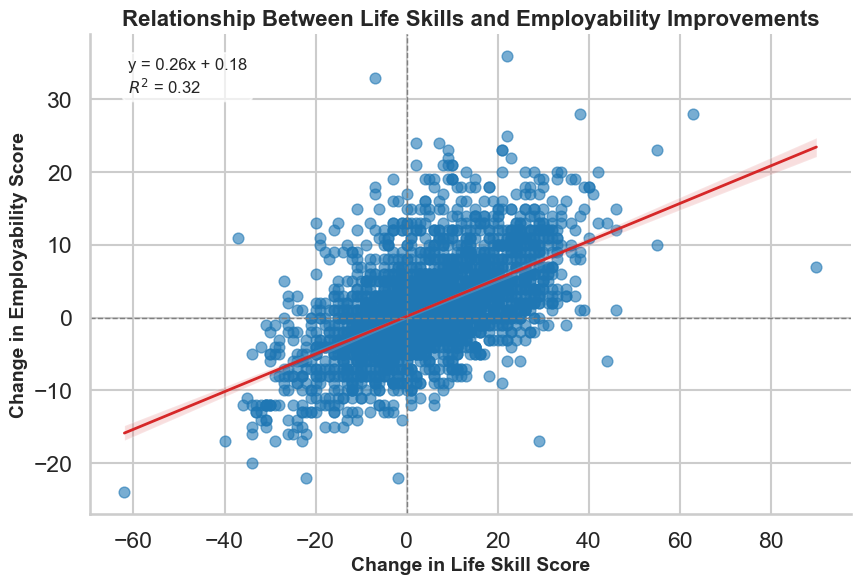

In [76]:
# Visual showing the relationship between change in Life Skills and Employability Scores 

from scipy.stats import linregress

# Regression
X = df_merged["life_skill_change"]
y = df_merged["employability_change"]
slope, intercept, r_value, p_value, std_err = linregress(X, y)

# Create lmplot with enhancements
sns.set(style="whitegrid", context="talk")

g = sns.lmplot(
    data=df_merged,
    x="life_skill_change",
    y="employability_change",
    height=6,
    aspect=1.5,
    markers=["o"],
    scatter_kws={'alpha': 0.6, 's': 60, 'color': '#1f77b4'},
    line_kws={'color': '#d62728', 'lw': 2}
)

# Add regression equation and R-squared
equation = f'y = {slope:.2f}x + {intercept:.2f}'
r_squared = f'$R^2$ = {r_value**2:.2f}'
plt.text(
    0.05, 0.95,
    f"{equation}\n{r_squared}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7)
)

# Axis labels and title
plt.xlabel("Change in Life Skill Score", fontsize=14, weight='bold')
plt.ylabel("Change in Employability Score", fontsize=14, weight='bold')
plt.title("Relationship Between Life Skills and Employability Improvements", fontsize=16, weight='bold')

# Optional: Add a vertical and horizontal line at zero
plt.axhline(0, color='gray', linestyle='--', lw=1)
plt.axvline(0, color='gray', linestyle='--', lw=1)

#plt.tight_layout()
plt.show()

K-means clustering is a widely utilized unsupervised machine learning algorithm that facilitates the partitioning of a dataset into a predetermined number of clusters based on the principle of minimizing within-cluster variance. Each data point is assigned to the cluster whose centroid is nearest in Euclidean space, making this technique particularly advantageous for uncovering latent structures in multivariate datasets absent of labeled outcomes.

In the present analysis, K-means clustering was employed to examine the distributional patterns of participants' life skills and employability scores, both prior to and following a targeted training intervention. The analytical objective was to determine whether discernible shifts in clustering structure could be attributed to the intervention. By systematically comparing cluster configurations and membership proportions before and after the training, the analysis aims to elucidate the extent to which participants’ competencies were influenced by the program.

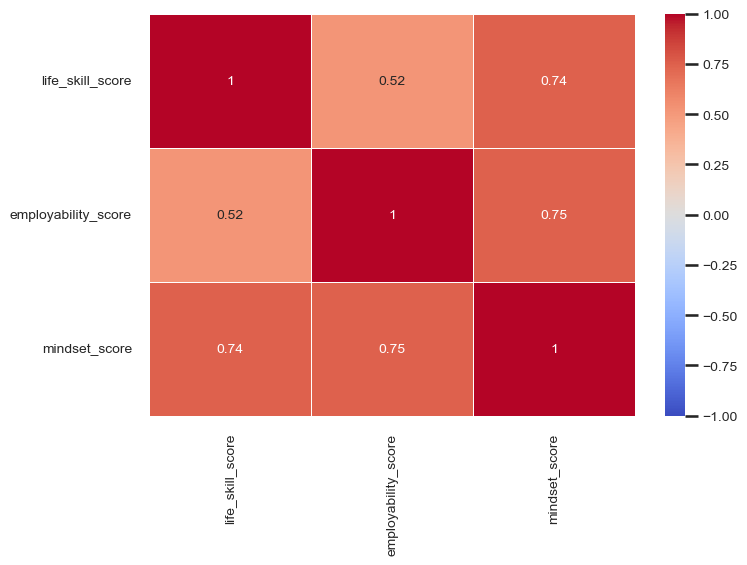

In [68]:
# compute  the correlation heatmap

correlation_matrix = df[['life_skill_score','employability_score','mindset_score']].corr()

# Plot trhe correlation matrix
plt.figure(figsize = (8,6))
heatmap = sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm', vmin = -1, vmax =1, linewidths =0.5, annot_kws = {"size" : 10})
plt.xticks(fontsize =10)
plt.yticks(fontsize =10) 

# reduce the font size of colorbar scale

colorbar = heatmap.collections[0].colorbar
colorbar.ax.tick_params(labelsize =10)


plt.tight_layout()

In [ ]:
# Load and filter data

df_pre = df[df['time_lsa'] == 'pre']
df_post = df[df['time_lsa'] == 'post']

# Select relevant columns
X = df_pre[['life_skill_score', 'employability_score']].dropna()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to find optimal number of clusters
wcss = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [ ]:
from kneed import KneeLocator

# Automatically find the elbow point
knee = KneeLocator(range(1, 11), wcss, curve='convex', direction='decreasing')
optimal_k = knee.knee
print(f'Optimal number of clusters: {optimal_k}')

In [ ]:
df = pd.read_csv(path)
df_post = df[df['time_lsa'] == 'post']

# Select relevant columns
X1 = df_post[['life_skill_score', 'employability_score']].dropna()

# Standardize the data
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(X)

# Elbow method to find optimal number of clusters
wcss1 = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X1_scaled)
    wcss1.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [ ]:
# Automatically find the elbow point
knee = KneeLocator(range(1, 11), wcss1, curve='convex', direction='decreasing')
optimal_k1 = knee.knee
print(f'Optimal number of clusters: {optimal_k}')

### Findings from K-means Clustering Analysis Before and After Training

The elbow method, based on an evaluation of the Within-Cluster Sum of Squares (WCSS), was employed to ascertain the optimal number of clusters. For both pre-training and post-training datasets, the inflection point of the WCSS curve clearly indicated that k = 3 was optimal. This convergence supports the stability of a three-cluster solution across temporal conditions and provides a robust framework for comparative analysis.So, in the code bellow,  we will run the clustering with K = 3 

In [ ]:
# Select and clean relevant columns
cols = ['life_skill_score', 'employability_score']
X = df_pre[cols].dropna().copy()
X1 = df_post[cols].dropna().copy()

# Standardize the features using separate scalers
scaler_pre = StandardScaler()
X_scaled = scaler_pre.fit_transform(X)

scaler_post = StandardScaler()
X1_scaled = scaler_post.fit_transform(X1)

# KMeans clustering
optimal_k = 3
kmeans_pre = KMeans(n_clusters=optimal_k, random_state=42)
X['cluster'] = kmeans_pre.fit_predict(X_scaled)

kmeans_post = KMeans(n_clusters=optimal_k, random_state=42)
X1['cluster'] = kmeans_post.fit_predict(X1_scaled)

# Get cluster centers and transform them back to original scale
centers_pre = scaler_pre.inverse_transform(kmeans_pre.cluster_centers_)
centers_post = scaler_post.inverse_transform(kmeans_post.cluster_centers_)

# Plotting side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Before Training
for cluster in range(optimal_k):
    axes[0].scatter(
        X[X['cluster'] == cluster]['life_skill_score'],
        X[X['cluster'] == cluster]['employability_score'],
        label=f'Cluster {cluster}'
    )

# Overlay pre-training cluster centers
axes[0].scatter(
    centers_pre[:, 0],
    centers_pre[:, 1],
    marker='X', s=200, c='black', label='Centroids'
)
axes[0].set_title('K-means Clustering Before Training')
axes[0].set_xlabel('Life Skills Score')
axes[0].set_ylabel('Employability Score')
axes[0].legend()
axes[0].grid(True)

# After Training
for cluster in range(optimal_k):
    axes[1].scatter(
        X1[X1['cluster'] == cluster]['life_skill_score'],
        X1[X1['cluster'] == cluster]['employability_score'],
        label=f'Cluster {cluster}'
    )

# Overlay post-training cluster centers
axes[1].scatter(
    centers_post[:, 0],
    centers_post[:, 1],
    marker='X', s=200, c='black', label='Centroids'
)
axes[1].set_title('K-means Clustering After Training')
axes[1].set_xlabel('Life Skills Score')
axes[1].set_ylabel('Employability Score')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# Assuming centers_pre and centers_post are your computed centroids (arrays with shape [3,2])
# For clarity, let's sort these centroids by life_skill_score (the first column)

# Sort indices by the first dimension (life_skill_score)
sorted_idx_pre = np.argsort(centers_pre[:, 0])
sorted_idx_post = np.argsort(centers_post[:, 0])

# Sort the centroids accordingly
centers_pre_sorted = centers_pre[sorted_idx_pre]
centers_post_sorted = centers_post[sorted_idx_post]

# Create a new figure for the trajectory visualization
fig, ax = plt.subplots(figsize=(8, 6))

# Plot pre-training centers as circles (red) and post-training centers as X's (blue)
ax.scatter(centers_pre_sorted[:, 0], centers_pre_sorted[:, 1], 
           marker='o', s=200, c='red', label='Pre')
ax.scatter(centers_post_sorted[:, 0], centers_post_sorted[:, 1], 
           marker='X', s=200, c='blue', label='Post ')

# Draw arrows connecting pre-training to post-training centers
for i in range(centers_pre_sorted.shape[0]):
    # Get the pre and post coordinates for the cluster
    x_pre, y_pre = centers_pre_sorted[i]
    x_post, y_post = centers_post_sorted[i]
    # Draw an arrow from the pre to the post center
    ax.annotate("",
                xy=(x_post, y_post), xycoords='data',
                xytext=(x_pre, y_pre), textcoords='data',
                arrowprops=dict(arrowstyle="->", color='gray', lw=2))

# Label the axes and add title and legend
ax.set_xlabel('Life Skills Score')
ax.set_ylabel('Employability Score')
ax.set_title('Trajectory of Cluster Centroids from Pre to Post')
ax.legend()
ax.grid(True)

plt.show()

#### How to Interpret the Visualization

Arrow Direction:
Each arrow points from the pre‑training center (red) to the post‑training center (blue). The direction shows whether the improvement is mostly along the life skills, employability, or both.

Arrow Length (Magnitude):
The length of each arrow reflects the Euclidean distance between the two centroids. A longer arrow indicates a larger overall shift, implying a stronger impact of the training for that cluster.

Relative Positions:
By comparing the placements of the centroids, I can see if most clusters improved (shifted upward/right) or if the improvement was uneven. For example, if one arrow is much shorter than the others, it may indicate that the corresponding group experienced less change.

This type of trajectory visualization complements the previous scatter plots by directly showing how the overall centers (average performance) have changed , helping me to assess the impact of training more intuitively.

### 6. Score Multivariate scatter plot

In [ ]:

# Split the dataset into pre- and post-training based on the 'time_lsa' column
df_pre = df[df['time_lsa'] == 'pre'].copy()
df_post = df[df['time_lsa'] == 'post'].copy()

# Select the columns of interest and drop rows with missing values
cols = ['life_skill_score', 'employability_score', 'mindset_score']
df_pre_scatter = df_pre[cols].dropna()
df_post_scatter = df_post[cols].dropna()

# Compute centroids (mean values) for each period
centroid_pre = df_pre_scatter.mean()
centroid_post = df_post_scatter.mean()

# Create a new figure with two subplots arranged side by side
fig = plt.figure(figsize=(16, 8))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

# Plot the Pre-training 3D scatter
sc1 = ax1.scatter(
    df_pre_scatter['life_skill_score'],
    df_pre_scatter['employability_score'],
    df_pre_scatter['mindset_score'],
    c='green', marker='o',
     alpha=0.7   # Make the points a bit see-through
    
)
ax1.set_title('Scores Scatter Plot - LSA Pre', fontsize=14, pad=20)
ax1.set_xlabel('Life Skills Score', fontsize=13, labelpad=10)
ax1.set_ylabel('Employability Score', fontsize=13, labelpad=10)
ax1.set_zlabel('Mindset Score', fontsize=13, labelpad=10)
ax1.tick_params(axis='x', labelsize=9)
ax1.tick_params(axis='y', labelsize=9)
ax1.tick_params(axis='z', labelsize=9)
ax1.grid(True)

# Overlay pre-training centroid (mean) as a large black "X"
ax1.scatter(
    centroid_pre['life_skill_score'],
    centroid_pre['employability_score'],
    centroid_pre['mindset_score'],
    marker='X', s=200, c='black', label='Centroid'
)
ax1.legend(prop={'size': 10})

# Plot the Post-training 3D scatter
sc2 = ax2.scatter(
    df_post_scatter['life_skill_score'],
    df_post_scatter['employability_score'],
    df_post_scatter['mindset_score'],
    c='green', marker='o'
)
ax2.set_title('Scores Scatter Plot - LSA Post', fontsize=14, pad=20)
ax2.set_xlabel('Life Skills Score', fontsize=13, labelpad=10)
ax2.set_ylabel('Employability Score', fontsize=13, labelpad=10)
ax2.set_zlabel('Mindset Score', fontsize=13, labelpad=10)
ax2.tick_params(axis='x', labelsize=9)
ax2.tick_params(axis='y', labelsize=9)
ax2.tick_params(axis='z', labelsize=9)
ax2.grid(True)

# Overlay post-training centroid (mean) as a large black "X"
ax2.scatter(
    centroid_post['life_skill_score'],
    centroid_post['employability_score'],
    centroid_post['mindset_score'],
    marker='X', s=200, c='black', label='Centroid'
)
ax2.legend(prop={'size': 10})

# Adjust the subplot layout to avoid clipping of labels/titles (tweak these as needed)
plt.subplots_adjust(left=0.05, right=0.95, wspace=0.3, bottom=0.1, top=0.9)

plt.show()


In [ ]:
# Split the dataset into pre- and post-training based on the 'time_lsa' column
df_pre = df[df['time_lsa'] == 'pre'].copy()
df_post = df[df['time_lsa'] == 'post'].copy()

# Define the columns of interest
cols = ['life_skill_score', 'employability_score', 'mindset_score']

# Clean the data by dropping rows with missing values in these columns
df_pre_clean = df_pre[cols].dropna()
df_post_clean = df_post[cols].dropna()

# --- Compute the Overall Mean for Each Group ---
mean_pre = df_pre_clean.mean()   # Pre-training overall mean for each column
mean_post = df_post_clean.mean() # Post-training overall mean for each column

# --- Create a 3D Trajectory Plot ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the pre-training mean as a red circle and the post-training mean as a blue X
ax.scatter(mean_pre['life_skill_score'], mean_pre['employability_score'], mean_pre['mindset_score'],
           color='red', marker='o', s=100, label='Pre-Training Mean')
ax.scatter(mean_post['life_skill_score'], mean_post['employability_score'], mean_post['mindset_score'],
           color='blue', marker='X', s=100, label='Post-Training Mean')

# Draw an arrow from the pre-training mean to the post-training mean
dx = mean_post['life_skill_score'] - mean_pre['life_skill_score']
dy = mean_post['employability_score'] - mean_pre['employability_score']
dz = mean_post['mindset_score'] - mean_pre['mindset_score']

ax.quiver(mean_pre['life_skill_score'], mean_pre['employability_score'], mean_pre['mindset_score'],
          dx, dy, dz, arrow_length_ratio=0.1, color='gray', linewidth=2)

# Set the axis labels, title, and legend
ax.set_xlabel('Life Skills Score', fontsize=9)
ax.set_ylabel('Employability Score', fontsize=9)
ax.set_zlabel('Mindset Score', fontsize=9)
ax.set_title('Trajectory of Overall Mean from Pre to Post LSA')
ax.legend(prop={'size': 8})
ax.grid(True)

# Adjust tick labels if necessary
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='z', labelsize=8)


# Adjust subplot margins to prevent clipping
plt.subplots_adjust(left=0.40, right=0.8, bottom=0.1, top=0.9)

plt.show()

Based on the 3D plot, the arrow from the red (pre-training) mean to the blue (post-training) mean appears to move up and to the right along all three axes—Life Skills, Employability, and Mindset. That indicates an overall improvement in these three measures at the group level. Here are some key takeaways:

1. Positive Shift Across All Axes : The arrow’s direction suggests that participants, on average, have higher life skills, higher employability, and better mindset after the training. This simultaneous movement in all three dimensions generally indicates a broad-based gain rather than improvement limited to just one metric.

2. Magnitude of Improvement: The length of the arrow reflects how far the mean values have shifted from pre to post. A noticeably long arrow means there’s a substantial overall difference. Even if it’s not huge in each individual metric, the combined 3D distance can be significant.

3. Consistency in Gains: Since this is the overall mean, the shift implies that on average participants progressed. However, it doesn’t capture individual variability—some participants may have improved more than others. If you also want to assess how consistent or widespread those gains are, you might look at variance or distribution shifts in each metric.

Overall Conclusion: Visually, the trajectory confirms that, as a whole, youth moved to a higher level on all three metrics. This provides straightforward evidence that the program  likely had a positive impact across multiple dimensions.In short, the takeaway is that the mean values for Life Skills, Employability, and Mindset have all increased from pre to post, showing a clear upward trend.

In [ ]:
# Load and filter data

df_pre = df[df['time_lsa'] == 'pre']
df_post = df[df['time_lsa'] == 'post']

# Select relevant columns
X = df_pre[['life_skill_score', 'employability_score','mindset_score']].dropna()

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method to find optimal number of clusters
wcss4 = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss4.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss4, marker='o')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

In [ ]:
# Automatically find the elbow point
knee = KneeLocator(range(1, 11), wcss4, curve='convex', direction='decreasing')
optimal_k1 = knee.knee
print(f'Optimal number of clusters: {optimal_k}')

### 7. Score clustering 

In [ ]:

# Assume the dataset includes a "period" column with values "pre" or "post"
df_pre = df[df['time_lsa'] == 'pre'].copy()
df_post = df[df['time_lsa'] == 'post'].copy()

# Define the columns to use, now including mindset_score
cols = ['life_skill_score', 'employability_score', 'mindset_score']

# Clean the data for each time period
X_pre = df_pre[cols].dropna().copy()
X_post = df_post[cols].dropna().copy()

# Standardize the features using separate scalers
scaler_pre = StandardScaler()
X_pre_scaled = scaler_pre.fit_transform(X_pre)

scaler_post = StandardScaler()
X_post_scaled = scaler_post.fit_transform(X_post)

# Apply KMeans clustering for each period
optimal_k = 3
kmeans_pre = KMeans(n_clusters=optimal_k, random_state=42)
X_pre['cluster'] = kmeans_pre.fit_predict(X_pre_scaled)

kmeans_post = KMeans(n_clusters=optimal_k, random_state=42)
X_post['cluster'] = kmeans_post.fit_predict(X_post_scaled)

# Get cluster centers and inverse-transform them to original scale
centers_pre = scaler_pre.inverse_transform(kmeans_pre.cluster_centers_)
centers_post = scaler_post.inverse_transform(kmeans_post.cluster_centers_)

# Plotting side-by-side in 3D
fig = plt.figure(figsize=(16, 6))

# 3D plot for Pre-Training data
ax1 = fig.add_subplot(121, projection='3d')
for cluster in range(optimal_k):
    cluster_data = X_pre[X_pre['cluster'] == cluster]
    ax1.scatter(
        cluster_data['life_skill_score'],
        cluster_data['employability_score'],
        cluster_data['mindset_score'],
        label=f'Cluster {cluster}'
    )
# Overlay pre-training cluster centers
ax1.scatter(
    centers_pre[:, 0],
    centers_pre[:, 1],
    centers_pre[:, 2],
    marker='X', s=100, c='black', label='Centroids'
)
ax1.set_title('Clustering - Pre LSA')
ax1.set_xlabel('Life Skills Score',fontsize =9)
ax1.set_ylabel('Employability Score',fontsize =9)
ax1.set_zlabel('Mindset Score',fontsize =9)
ax1.legend(prop={'size': 8})
ax1.grid(True)


# Adjust tick labels if necessary
ax1.tick_params(axis='x', labelsize=8)
ax1.tick_params(axis='y', labelsize=8)
ax1.tick_params(axis='z', labelsize=8)

# 3D plot for Post-Training data
ax2 = fig.add_subplot(122, projection='3d')
for cluster in range(optimal_k):
    cluster_data = X_post[X_post['cluster'] == cluster]
    ax2.scatter(
        cluster_data['life_skill_score'],
        cluster_data['employability_score'],
        cluster_data['mindset_score'],
        label=f'Cluster {cluster}'
    )
# Overlay post-training cluster centers
ax2.scatter(
    centers_post[:, 0],
    centers_post[:, 1],
    centers_post[:, 2],
    marker='X', s=100, c='black', label='Centroids'
)
ax2.set_title('Clustering - Post LSA')
ax2.set_xlabel('Life Skills Score',fontsize =9)
ax2.set_ylabel('Employability Score',fontsize =9)
ax2.set_zlabel('Mindset Score',fontsize =9)
ax2.legend(prop={'size': 8})
ax2.grid(True)


# Adjust tick labels if necessary
ax2.tick_params(axis='x', labelsize=8)
ax2.tick_params(axis='y', labelsize=8)
ax2.tick_params(axis='z', labelsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Define the column names (same order as in your scaler and k-means)
cols = ['life_skill_score', 'employability_score', 'mindset_score']

# Create a DataFrame for the pre-training centroids
df_centers_pre = pd.DataFrame(centers_pre, columns=cols)
# Optional: Add a cluster column (0-indexed)
df_centers_pre['cluster'] = range(optimal_k)
# Optionally, reorder columns if you want cluster first
df_centers_pre = df_centers_pre[['cluster'] + cols]

# Create a DataFrame for the post-training centroids
df_centers_post = pd.DataFrame(centers_post, columns=cols)
df_centers_post['cluster'] = range(optimal_k)
df_centers_post = df_centers_post[['cluster'] + cols]

# Print out the tables
print("Pre-training Centroids:")
print(df_centers_pre)
print("\nPost-training Centroids:")
print(df_centers_post)

From a quick glance at this 3D plot, here’s the high-level takeaway:

1. All Clusters Shifted Upward

Each arrow points generally toward higher values on all three axes—Life Skills Score, Employability Score, and Mindset Score. This suggests the training had an overall positive effect across the board.

2. Magnitude of Improvement Varies

The lengths of the arrows differ, implying that some clusters experienced a bigger jump than others. A longer arrow typically means a more substantial overall improvement in these combined dimensions.

3Baseline Influences Post-Training Position

The cluster that started higher on these metrics is still the top performer post-training, while the more moderate cluster(s) also improved but remain in a lower relative position. It’s a common pattern: everyone moves upward, but the starting point still influences the final position.

Next Steps for Interpretation

Numerical Differences: You can compute the exact changes (e.g., 
Δ
Δ life skills, 
Δ
Δ employability, 
Δ
Δ mindset) to quantify which dimension improved most for each cluster.

Cluster Composition: Investigate whether individuals from lower-scoring groups moved into higher brackets or if gaps persisted between groups.

Overall, the 3D trajectory arrows are showing that each centroid traveled to a region of higher average scores on all three metrics, reinforcing that the training has had a positive impact across life skills, employability, and mindset.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # enable 3D plotting

# Sort the centroids for alignment
sorted_idx_pre = np.argsort(centers_pre[:, 0])
sorted_idx_post = np.argsort(centers_post[:, 0])

centers_pre_sorted = centers_pre[sorted_idx_pre]
centers_post_sorted = centers_post[sorted_idx_post]

# Create the 3D figure
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot pre-training centers
ax.scatter(centers_pre_sorted[:, 0], centers_pre_sorted[:, 1], centers_pre_sorted[:, 2],
           marker='o', s=100, c='red', label='Pre-training Center')

# Plot post-training centers
ax.scatter(centers_post_sorted[:, 0], centers_post_sorted[:, 1], centers_post_sorted[:, 2],
           marker='X', s=100, c='blue', label='Post-training Center')

# Draw arrows and add cluster labels
for i in range(centers_pre_sorted.shape[0]):
    x_pre, y_pre, z_pre = centers_pre_sorted[i]
    x_post, y_post, z_post = centers_post_sorted[i]
    dx = x_post - x_pre
    dy = y_post - y_pre
    dz = z_post - z_pre
    
    # Draw arrow
    ax.quiver(x_pre, y_pre, z_pre, dx, dy, dz, arrow_length_ratio=0.1, color='gray', linewidth=2)
    
    # Add label near the post-training centroid
    ax.text(x_post + 1, y_post + 1, z_post + 1, f'Cluster {i}', color='black', fontsize=9)

# Axes labels and title
ax.set_xlabel('Life Skills Score', fontsize=9)
ax.set_ylabel('Employability Score', fontsize=9)
ax.set_zlabel('Mindset Score', fontsize=9)
ax.set_title('Trajectory of Cluster Centroids from Pre to Post LSA')
ax.legend(prop={'size': 8})
ax.grid(True)

# Tick adjustments
ax.tick_params(axis='x', labelsize=8)
ax.tick_params(axis='y', labelsize=8)
ax.tick_params(axis='z', labelsize=8)

# Margin adjustment
plt.subplots_adjust(left=0.30, right=0.8, bottom=0.1, top=0.9)

plt.show()


###  Age analysis 

### Gender analysis

In [ ]:
# Define the mapping for gender dataframe
mapping = {
    "female": "female",
    "male": "male",
    2.0: "male",
    1.0: "female",
    "other": "other",
    4.0:"other"
}

# Identify the columns by creating a list
cols = ['gender']

# Loop through each column, clean, replace, and convert
for col in cols:
    # Use lambda to call strip() only if the value is a string
    #df[col] = df[col].apply(lambda x: x.strip() if isinstance(x, str) else x)
    # Replace text responses with numeric values
    df[col] = df[col].replace(mapping)   

In [ ]:
df['gender'].value_counts(normalize =True)

In [ ]:
df_pre_female = df[(df['time_lsa'] == 'pre') & (df['gender'] == "female")]
df_post_female = df[(df['time_lsa'] == 'post') & (df['gender'] == "female")]
df_pre_male = df[(df['time_lsa'] == 'pre') & (df['gender'] == "male")]
df_post_male = df[(df['time_lsa'] == 'post') & (df['gender'] == "male")]

### Life skill score by gender

In [ ]:
#  FEMALE LIFE SKILL PRE AND POST DESCRIPTIVE STATISTICS 
summary = {
    "Pre": df_pre_female["life_skill_score"].describe(),
    "Post": df_post_female["life_skill_score"].describe()
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T

# Calculate standard error of the mean (SEM)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

# 95% confidence interval using z = 1.96
z = 1.96
summary_df["mean_CI_lower"] = summary_df["mean"] - z * summary_df["sem"]
summary_df["mean_CI_upper"] = summary_df["mean"] + z * summary_df["sem"]

# Round for cleaner display
summary_df = summary_df.round(2)

# Optional: drop SEM column if you don’t want it in the final output
# summary_df.drop(columns=["sem"], inplace=True)

# Display the updated summary
summary_df

In [ ]:
# FEMALE LIFE SKILL PRE AND POST - MEAN TEST

# Filter Pre and keep only 'id' and 'life_skill_score' for females
df_pre_female = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'female')]
df_pre_female = df_pre_female[["id", "life_skill_score"]]
df_pre_female = df_pre_female.rename(columns={"life_skill_score": "life_skill_pre"})

# Filter Post and keep only 'id' and 'life_skill_score' for females
df_post_female = df[(df['time_lsa'] == 'post') & (df['gender'] == 'female')]
df_post_female = df_post_female[["id", "life_skill_score"]]
df_post_female = df_post_female.rename(columns={"life_skill_score": "life_skill_post"})

# Merge on 'id'
merged_female = pd.merge(df_pre_female, df_post_female, on="id", how="inner")

# Drop missing
paired_female = merged_female.dropna(subset=["life_skill_pre", "life_skill_post"])

# Wilcoxon test
stat, p_value = wilcoxon(paired_female["life_skill_pre"], paired_female["life_skill_post"])

print("Wilcoxon Test Statistic (Female):", stat)
print("p-value (Female):", p_value)



In [ ]:
# MALE LIFE SKILLS SCORE PRE AND POST - DESCRIPTIVE STATISTICS
summary = {
    "Pre": df_pre_male["life_skill_score"].describe(),
    "Post": df_post_male["life_skill_score"].describe()
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T

# Calculate standard error of the mean (SEM)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

# 95% confidence interval using z = 1.96
z = 1.96
summary_df["mean_CI_lower"] = summary_df["mean"] - z * summary_df["sem"]
summary_df["mean_CI_upper"] = summary_df["mean"] + z * summary_df["sem"]

# Round for cleaner display
summary_df = summary_df.round(2)

# Optional: drop SEM column if you don’t want it in the final output
# summary_df.drop(columns=["sem"], inplace=True)

# Display the updated summary
summary_df

In [ ]:
# MALE LIFE SKILL PRE AND POST - MEAN TEST

# Filter Pre and keep only 'id' and 'life_skill_score' for females
df_pre_male = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'male')]
df_pre_male = df_pre_male[["id", "life_skill_score"]]
df_pre_male = df_pre_male.rename(columns={"life_skill_score": "life_skill_pre"})

# Filter Post and keep only 'id' and 'life_skill_score' for females
df_post_male = df[(df['time_lsa'] == 'post') & (df['gender'] == 'male')]
df_post_male = df_post_male[["id", "life_skill_score"]]
df_post_male = df_post_male.rename(columns={"life_skill_score": "life_skill_post"})

# Merge on 'id'
merged_male = pd.merge(df_pre_male, df_post_male, on="id", how="inner")

# Drop missing
paired_male = merged_male.dropna(subset=["life_skill_pre", "life_skill_post"])

# Wilcoxon test
stat, p_value = wilcoxon(paired_male["life_skill_pre"], paired_male["life_skill_post"])

print("Wilcoxon Test Statistic (Male):", stat)
print("p-value (Male):", p_value)


In [ ]:
### MALE AND FEMALE POST, MEAN TEST DIFFERENCES

# Subset data
df_post_female = df[(df['time_lsa'] == 'post') & (df['gender'] == 'female')]
df_post_male = df[(df['time_lsa'] == 'post') & (df['gender'] == 'male')]

# Extract scores
life_skills_male = df_post_male['life_skill_score'].dropna()
life_skills_female = df_post_female['life_skill_score'].dropna()

# Calculate means for display
mean_male = life_skills_male.mean()
mean_female = life_skills_female.mean()

print(f"Life Skills Score - Male: {mean_male:.2f}")
print(f"Life Skills Score - Female: {mean_female:.2f}")

# Mann–Whitney U Test
stat_mwu, p_mwu = mannwhitneyu(life_skills_male, life_skills_female, alternative='two-sided')

print(f"\nMann–Whitney U Test:")
print(f"U statistic = {stat_mwu:.2f}")
print(f"p-value = {p_mwu:.4f}")

# Welch's t-test
stat_t, p_t = ttest_ind(life_skills_male, life_skills_female, equal_var=False)

print(f"\nIndependent t-test (Welch’s):")
print(f"t-statistic = {stat_t:.2f}")
print(f"p-value = {p_t:.4f}")

# Interpretation
if p_t < 0.05:
    print("✅ Life Skills: Statistically significant difference between male and female.")
else:
    print("🚫 Life Skills: No statistically significant difference between male and female.")


### Employability score by gender

In [ ]:
df_pre_female = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'female')]
df_post_female = df[(df['time_lsa'] == 'post') & (df['gender'] == 'female')]
df_pre_male = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'male')]
df_post_male = df[(df['time_lsa'] == 'post') & (df['gender'] == 'male')]

In [ ]:
#  FEMALE EMPLOYABILITY PRE AND POST DESCRIPTIVE STATISTICS 
summary = {
    "Pre": df_pre_female["employability_score"].describe(),
    "Post": df_post_female["employability_score"].describe()
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T

# Calculate standard error of the mean (SEM)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

# 95% confidence interval using z = 1.96
z = 1.96
summary_df["mean_CI_lower"] = summary_df["mean"] - z * summary_df["sem"]
summary_df["mean_CI_upper"] = summary_df["mean"] + z * summary_df["sem"]

# Round for cleaner display
summary_df = summary_df.round(2)

# Optional: drop SEM column if you don’t want it in the final output
# summary_df.drop(columns=["sem"], inplace=True)

# Display the updated summary
summary_df

In [ ]:
# FEMALE EMPLOYABILITY PRE AND POST MEAN TEST

# Filter Pre and keep only 'id' and 'life_skill_score' for females
df_pre_female = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'female')]
df_pre_female = df_pre_female[["id", "employability_score"]]
df_pre_female = df_pre_female.rename(columns={"employability_score": "employability_pre"})

# Filter Post and keep only 'id' and 'life_skill_score' for females
df_post_female = df[(df['time_lsa'] == 'post') & (df['gender'] == 'female')]
df_post_female = df_post_female[["id", "employability_score"]]
df_post_female = df_post_female.rename(columns={"employability_score": "employability_post"})

# Merge on 'id'
merged_female = pd.merge(df_pre_female, df_post_female, on="id", how="inner")

# Drop missing
paired_female = merged_female.dropna(subset=["employability_pre", "employability_post"])

# Wilcoxon test
stat, p_value = wilcoxon(paired_female["employability_pre"], paired_female["employability_post"])

print("Wilcoxon Test Statistic (Female):", stat)
print("p-value (Female):", p_value)



In [ ]:
#  MALE EMPLOYABILITY PRE AND POST DESCRIPTIVE STATISTICS 
summary = {
    "Pre": df_pre_male["employability_score"].describe(),
    "Post": df_post_male["employability_score"].describe()
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T

# Calculate standard error of the mean (SEM)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

# 95% confidence interval using z = 1.96
z = 1.96
summary_df["mean_CI_lower"] = summary_df["mean"] - z * summary_df["sem"]
summary_df["mean_CI_upper"] = summary_df["mean"] + z * summary_df["sem"]

# Round for cleaner display
summary_df = summary_df.round(2)

# Optional: drop SEM column if you don’t want it in the final output
# summary_df.drop(columns=["sem"], inplace=True)

# Display the updated summary
summary_df

In [ ]:
# MALE EMPLOYABILITY PRE AND POST MEAN TEST

# Filter Pre and keep only 'id' and 'life_skill_score' for females
df_pre_male = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'male')]
df_pre_male = df_pre_male[["id", "employability_score"]]
df_pre_male = df_pre_male.rename(columns={"employability_score": "employability_pre"})

# Filter Post and keep only 'id' and 'life_skill_score' for females
df_post_male = df[(df['time_lsa'] == 'post') & (df['gender'] == 'male')]
df_post_male = df_post_male[["id", "employability_score"]]
df_post_male = df_post_male.rename(columns={"employability_score": "employability_post"})

# Merge on 'id'
merged_male = pd.merge(df_pre_male, df_post_male, on="id", how="inner")

# Drop missing
paired_male = merged_male.dropna(subset=["employability_pre", "employability_post"])

# Wilcoxon test
stat, p_value = wilcoxon(paired_male["employability_pre"], paired_male["employability_post"])

print("Wilcoxon Test Statistic (Male):", stat)
print("p-value (Male):", p_value)



In [ ]:
### MALE AND FEMALE POST EMPLOYABILITY , MEAN TEST DIFFERENCES 

# Subset data
df_post_female = df[(df['time_lsa'] == 'post') & (df['gender'] == 'female')]
df_post_male = df[(df['time_lsa'] == 'post') & (df['gender'] == 'male')]

# Extract scores
employability_male = df_post_male['employability_score'].dropna()
employability_female = df_post_female['employability_score'].dropna()

# Calculate means for display
mean_male = employability_male.mean()
mean_female = employability_female.mean()

print(f"Employability Score - Male: {mean_male:.2f}")
print(f"Employability  Score - Female: {mean_female:.2f}")

# Mann–Whitney U Test
stat_mwu, p_mwu = mannwhitneyu(life_skills_male, life_skills_female, alternative='two-sided')

print(f"\nMann–Whitney U Test:")
print(f"U statistic = {stat_mwu:.2f}")
print(f"p-value = {p_mwu:.4f}")

# Welch's t-test
stat_t, p_t = ttest_ind(life_skills_male, life_skills_female, equal_var=False)

print(f"\nIndependent t-test (Welch’s):")
print(f"t-statistic = {stat_t:.2f}")
print(f"p-value = {p_t:.4f}")

# Interpretation
if p_t < 0.05:
    print("✅ Employability : Statistically significant difference between male and female.")
else:
    print("🚫 Employability: No statistically significant difference between male and female.")

### Mindset score by gender

In [ ]:
df_pre_female = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'female')]
df_post_female = df[(df['time_lsa'] == 'post') & (df['gender'] == 'female')]
df_pre_male = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'male')]
df_post_male = df[(df['time_lsa'] == 'post') & (df['gender'] == 'male')]

In [ ]:
#  FEMALE MINDSET PRE AND POST DESCRIPTIVE STATISTICS 
summary = {
    "Pre": df_pre_female["mindset_score"].describe(),
    "Post": df_post_female["mindset_score"].describe()
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T

# Calculate standard error of the mean (SEM)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

# 95% confidence interval using z = 1.96
z = 1.96
summary_df["mean_CI_lower"] = summary_df["mean"] - z * summary_df["sem"]
summary_df["mean_CI_upper"] = summary_df["mean"] + z * summary_df["sem"]

# Round for cleaner display
summary_df = summary_df.round(2)

# Optional: drop SEM column if you don’t want it in the final output
# summary_df.drop(columns=["sem"], inplace=True)

# Display the updated summary
summary_df

In [ ]:
# FEMALE MINDSET PRE AND POST MEAN TEST

# Filter Pre and keep only 'id' and 'life_skill_score' for females
df_pre_female = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'female')]
df_pre_female = df_pre_female[["id", "mindset_score"]]
df_pre_female = df_pre_female.rename(columns={"mindset_score": "mindset_pre"})

# Filter Post and keep only 'id' and 'life_skill_score' for females
df_post_female = df[(df['time_lsa'] == 'post') & (df['gender'] == 'female')]
df_post_female = df_post_female[["id", "mindset_score"]]
df_post_female = df_post_female.rename(columns={"mindset_score": "mindset_post"})

# Merge on 'id'
merged_female = pd.merge(df_pre_female, df_post_female, on="id", how="inner")

# Drop missing
paired_female = merged_female.dropna(subset=["mindset_pre", "mindset_post"])

# Wilcoxon test
stat, p_value = wilcoxon(paired_female["mindset_pre"], paired_female["mindset_post"])

print("Wilcoxon Test Statistic (Female):", stat)
print("p-value (Female):", p_value)

In [ ]:
#  MALE MINDSET PRE AND POST DESCRIPTIVE STATISTICS 
summary = {
    "Pre": df_pre_male["mindset_score"].describe(),
    "Post": df_post_male ["mindset_score"].describe()
}

# Convert to DataFrame
summary_df = pd.DataFrame(summary).T

# Calculate standard error of the mean (SEM)
summary_df["sem"] = summary_df["std"] / np.sqrt(summary_df["count"])

# 95% confidence interval using z = 1.96
z = 1.96
summary_df["mean_CI_lower"] = summary_df["mean"] - z * summary_df["sem"]
summary_df["mean_CI_upper"] = summary_df["mean"] + z * summary_df["sem"]

# Round for cleaner display
summary_df = summary_df.round(2)

# Optional: drop SEM column if you don’t want it in the final output
# summary_df.drop(columns=["sem"], inplace=True)

# Display the updated summary
summary_df

In [ ]:
# MALE MINDSET PRE AND POST MEAN TEST

# Filter Pre and keep only 'id' and 'life_skill_score' for females
df_pre_male = df[(df['time_lsa'] == 'pre') & (df['gender'] == 'male')]
df_pre_male = df_pre_male[["id", "mindset_score"]]
df_pre_male = df_pre_male.rename(columns={"mindset_score": "mindset_pre"})

# Filter Post and keep only 'id' and 'life_skill_score' for females
df_post_male = df[(df['time_lsa'] == 'post') & (df['gender'] == 'male')]
df_post_male = df_post_male[["id", "mindset_score"]]
df_post_male = df_post_male.rename(columns={"mindset_score": "mindset_post"})

# Merge on 'id'
merged_male = pd.merge(df_pre_male, df_post_male, on="id", how="inner")

# Drop missing
paired_male = merged_male.dropna(subset=["mindset_pre", "mindset_post"])

# Wilcoxon test
stat, p_value = wilcoxon(paired_male["mindset_pre"], paired_male["mindset_post"])

print("Wilcoxon Test Statistic (Male):", stat)
print("p-value (Male):", p_value)

In [ ]:
### MALE AND FEMALE POST MINDSET , MEAN TEST DIFFERENCES 

# Subset data
df_post_female = df[(df['time_lsa'] == 'post') & (df['gender'] == 'female')]
df_post_male = df[(df['time_lsa'] == 'post') & (df['gender'] == 'male')]

# Extract scores
mindset_male = df_post_male['mindset_score'].dropna()
mindset_female = df_post_female['mindset_score'].dropna()

# Calculate means for display
mean_male = mindset_male.mean()
mean_female = mindset_female.mean()

print(f"Mindset Score - Male: {mean_male:.2f}")
print(f"Mindset  Score - Female: {mean_female:.2f}")

# Mann–Whitney U Test
stat_mwu, p_mwu = mannwhitneyu(mindset_male, mindset_female, alternative='two-sided')

print(f"\nMann–Whitney U Test:")
print(f"U statistic = {stat_mwu:.2f}")
print(f"p-value = {p_mwu:.4f}")

# Welch's t-test
stat_t, p_t = ttest_ind(mindset_male, mindset_female, equal_var=False)

print(f"\nIndependent t-test (Welch’s):")
print(f"t-statistic = {stat_t:.2f}")
print(f"p-value = {p_t:.4f}")

# Interpretation
if p_t < 0.05:
    print("✅ Mindset : Statistically significant difference between male and female.")
else:
    print("🚫 Mindset: No statistically significant difference between male and female.")